In [41]:
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset with error handling
FILE_PATH = "Advertising.csv"
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Error: '{FILE_PATH}' not found in current directory.")

df = pd.read_csv(FILE_PATH)

# Remove unnecessary index column safely
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Separate features and target
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on test data
predictions = model.predict(X_test)

# Display clean formatted output
print("=" * 45)
print("   PREDICTED FUTURE SALES (FIRST 10 ROWS)   ")
print("=" * 45)
for i, pred in enumerate(predictions[:10], start=1):
    print(f" Record {i:02d}: Estimated Sales -> {pred:.2f} units")
print("=" * 45)

   PREDICTED FUTURE SALES (FIRST 10 ROWS)   
 Record 01: Estimated Sales -> 16.41 units
 Record 02: Estimated Sales -> 20.89 units
 Record 03: Estimated Sales -> 21.55 units
 Record 04: Estimated Sales -> 10.61 units
 Record 05: Estimated Sales -> 22.11 units
 Record 06: Estimated Sales -> 13.11 units
 Record 07: Estimated Sales -> 21.06 units
 Record 08: Estimated Sales -> 7.46 units
 Record 09: Estimated Sales -> 13.61 units
 Record 10: Estimated Sales -> 15.16 units


In [42]:
from sklearn.preprocessing import StandardScaler

# --- DATA CLEANING VERIFICATION ---
# Check data health before modeling
print("=" * 45)
print("   DATA CLEANING & QUALITY CHECK   ")
print("=" * 45)
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

# --- FEATURE SELECTION ---
# Features (X) and Target (y) are already isolated from Cell 1
print("\n" + "=" * 45)
print("   FEATURE SELECTION PREVIEW   ")
print("=" * 45)
print("Selected Features (X):", list(X.columns))

# --- DATA TRANSFORMATION (SCALING) ---
# Scale features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n" + "=" * 45)
print("   DATA TRANSFORMATION (FIRST 5 ROWS)   ")
print("=" * 45)
print("Scaled Features (TV, Radio, Newspaper):")
print(X_scaled[:5])
print("=" * 45)

   DATA CLEANING & QUALITY CHECK   
Missing Values per Column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Total Duplicate Rows: 0

   FEATURE SELECTION PREVIEW   
Selected Features (X): ['TV', 'Radio', 'Newspaper']

   DATA TRANSFORMATION (FIRST 5 ROWS)   
Scaled Features (TV, Radio, Newspaper):
[[ 0.96985227  0.98152247  1.77894547]
 [-1.19737623  1.08280781  0.66957876]
 [-1.51615499  1.52846331  1.78354865]
 [ 0.05204968  1.21785493  1.28640506]
 [ 0.3941822  -0.84161366  1.28180188]]


In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Split the transformed data (using X_scaled from Cell 2)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize and train the Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Forecast sales using the test set
y_pred = model.predict(X_test)

# Display formatted forecast results
print("=" * 45)
print("   REGRESSION MODEL SALES FORECAST (TOP 10)   ")
print("=" * 45)
for i, pred in enumerate(y_pred[:10], start=1):
    print(f" Forecast {i:02d}: Predicted Sales -> {pred:.2f} units")

# Calculate model performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 45)
print("   MODEL EVALUATION METRICS   ")
print("=" * 45)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Accuracy Score): {r2:.4f} ({r2*100:.2f}%)")
print("=" * 45)

   REGRESSION MODEL SALES FORECAST (TOP 10)   
 Forecast 01: Predicted Sales -> 16.41 units
 Forecast 02: Predicted Sales -> 20.89 units
 Forecast 03: Predicted Sales -> 21.55 units
 Forecast 04: Predicted Sales -> 10.61 units
 Forecast 05: Predicted Sales -> 22.11 units
 Forecast 06: Predicted Sales -> 13.11 units
 Forecast 07: Predicted Sales -> 21.06 units
 Forecast 08: Predicted Sales -> 7.46 units
 Forecast 09: Predicted Sales -> 13.61 units
 Forecast 10: Predicted Sales -> 15.16 units

   MODEL EVALUATION METRICS   
Root Mean Squared Error (RMSE): 1.7816
R-squared (Accuracy Score): 0.8994 (89.94%)


   LINEAR CORRELATION WITH SALES   
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

   REGRESSION COEFFICIENTS (MARGINAL IMPACT)   
 TV         : 0.045765
 Radio      : 0.188530
 Newspaper  : -0.001037

 Baseline Sales (Intercept): 2.938889


C:\Users\Raza\AppData\Local\Temp\ipykernel_15308\2256541194.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel", y="Coefficient", data=impact_df, palette="viridis")


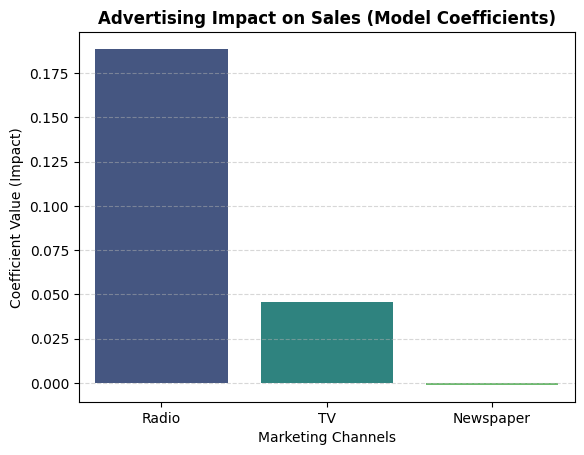

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CORRELATION ANALYSIS ---
print("=" * 45)
print("   LINEAR CORRELATION WITH SALES   ")
print("=" * 45)
correlations = df.corr()["Sales"].sort_values(ascending=False)
print(correlations)

# --- REGRESSION COEFFICIENTS (IMPACT ANALYSIS) ---
analysis_model = LinearRegression()
analysis_model.fit(X, y)

print("\n" + "=" * 45)
print("   REGRESSION COEFFICIENTS (MARGINAL IMPACT)   ")
print("=" * 45)
for feature, coef in zip(X.columns, analysis_model.coef_):
    print(f" {feature:<10} : {coef:.6f}")

print(f"\n Baseline Sales (Intercept): {analysis_model.intercept_:.6f}")
print("=" * 45)

# --- GRAPH: VISUALIZING ADVERTISING IMPACT ---
# Create DataFrame for sorted coefficients to plot
impact_df = pd.DataFrame({
    "Channel": X.columns,
    "Coefficient": analysis_model.coef_
}).sort_values(by="Coefficient", ascending=False)

# Generate professional bar chart and save it as an image
sns.barplot(x="Channel", y="Coefficient", data=impact_df, palette="viridis")
plt.title("Advertising Impact on Sales (Model Coefficients)", fontsize=12, fontweight="bold")
plt.xlabel("Marketing Channels", fontsize=10)
plt.ylabel("Coefficient Value (Impact)", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig("advertising_impact_analysis.png", bbox_inches="tight")

In [47]:
# Strategic business recommendations
print("=== Business Strategy Insights ===")
print(
    f"- Prioritize Radio: Highest impact per dollar spent ({model.coef_[1]:.4f})."
)
print(
    f"- Scale TV: Strong secondary positive impact ({model.coef_[0]:.4f})."
)
print(
    f"- Optimize Newspaper: Negligible impact ({model.coef_[2]:.4f}). Reduce budget here."
)

=== Business Strategy Insights ===
- Prioritize Radio: Highest impact per dollar spent (0.1885).
- Scale TV: Strong secondary positive impact (0.0458).
- Optimize Newspaper: Negligible impact (-0.0010). Reduce budget here.
